# Dense scan — 2σ vs 1σ PDG-faithfulness comparison

Compare the M_KK exclusion plots and Yukawa distributions under two acceptance gates:

- **2σ-PDG** (production gate, what the dense scan stored): per-quark mass log-residuals within 2× PDG-2024 fractional uncertainty (with a 0.3% floor); per-CKM-element relative residuals within 2× PDG-2024 fractional uncertainty.
- **1σ-PDG** (post-hoc filter, halved tolerances): same metric, with all tolerance vectors halved.

The 1σ-accepted set is a strict subset of the 2σ-accepted set. Per-quark + per-CKM residuals were precomputed by `scripts/compute_per_quark_residuals.py` (parallel refit on a SLURM compute node) and saved to `derived/residuals_per_point.npz`. This notebook reads them and applies the 1σ filter.

In [1]:
from __future__ import annotations
import json, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from quarkConstraints.scan import _default_per_flavor_mass_tolerances, _CKM_2SIGMA_RELATIVE_DEFAULT
from scripts.plot_publication_figures import (
    _load_results, _extract_arrays, _apply_publication_convention,
    build_exclusion_boundaries_figure, build_mkk_bound_comparison_figure,
    DEFAULT_PUBLICATION_XI_KK,
)

RUN_DIR = REPO_ROOT / 'scan_outputs' / 'dense_20260506T141321'
JSONL = RUN_DIR / 'merged' / 'results.jsonl'
ACCEPTED_2S_CSV = RUN_DIR / 'derived' / 'accepted_points.csv'
YUKAWAS_2S_CSV = RUN_DIR / 'derived' / 'accepted_points_with_yukawas.csv'
RESIDUALS_NPZ = RUN_DIR / 'derived' / 'residuals_per_point.npz'
FIG_DIR = REPO_ROOT / 'results' / 'figures' / 'quark'
FIG_DIR.mkdir(parents=True, exist_ok=True)

tol_up, tol_down = _default_per_flavor_mass_tolerances()
tol_ckm = _CKM_2SIGMA_RELATIVE_DEFAULT.copy()
TOLS_2S = {'up': tol_up, 'down': tol_down, 'ckm': tol_ckm}
TOLS_1S = {k: v / 2.0 for k, v in TOLS_2S.items()}

print('2σ tolerances'); print(f'  mass_up   = {tol_up}'); print(f'  mass_down = {tol_down}'); print(f'  ckm       = {tol_ckm}')
print('1σ = 2σ / 2')

2σ tolerances
  mass_up   = [0.4537037  0.00722702 0.00861538]
  mass_down = [0.18297872 0.0171123  0.00334688]
  ckm       = [0.0044 0.072  0.1    0.085 ]
1σ = 2σ / 2


## Step 1 — Load 2σ accepted set + precomputed per-point residuals

In [2]:
df_2s = pd.read_csv(ACCEPTED_2S_CSV)
print(f'2σ accepted points: {len(df_2s):,}')

if not RESIDUALS_NPZ.exists():
    raise FileNotFoundError(f'Run scripts/compute_per_quark_residuals.py first; expected {RESIDUALS_NPZ}')
data_npz = np.load(RESIDUALS_NPZ, allow_pickle=True)
mres_up = data_npz['mass_residuals_up']
mres_dn = data_npz['mass_residuals_down']
ckm_res = data_npz['ckm_residuals']
point_ids_npz = data_npz['point_id'].astype(str)
print(f'residuals shape: up={mres_up.shape}, down={mres_dn.shape}, ckm={ckm_res.shape}')

# Sanity: row order must match.
assert list(point_ids_npz) == list(df_2s['point_id'].astype(str)), 'point_id ordering mismatch between CSV and NPZ'
print('row alignment OK')

2σ accepted points: 83,961
residuals shape: up=(83961, 3), down=(83961, 3), ckm=(83961, 4)
row alignment OK


## Step 2 — Apply 1σ filter

In [3]:
passes_mass_2s = (np.abs(mres_up) <= TOLS_2S['up']).all(axis=1) & (np.abs(mres_dn) <= TOLS_2S['down']).all(axis=1)
passes_ckm_2s  = (np.abs(ckm_res) <= TOLS_2S['ckm']).all(axis=1)
passes_2s = passes_mass_2s & passes_ckm_2s
passes_mass_1s = (np.abs(mres_up) <= TOLS_1S['up']).all(axis=1) & (np.abs(mres_dn) <= TOLS_1S['down']).all(axis=1)
passes_ckm_1s  = (np.abs(ckm_res) <= TOLS_1S['ckm']).all(axis=1)
passes_1s = passes_mass_1s & passes_ckm_1s

n_2s = int(passes_2s.sum())
n_1s = int(passes_1s.sum())
print(f'2σ accepted (sanity): {n_2s:,} / {len(df_2s):,}')
print(f'1σ accepted        : {n_1s:,} / {len(df_2s):,}  ({100 * n_1s / len(df_2s):.1f}%)')
print(f'dropped 2σ → 1σ    : {n_2s - n_1s:,}')

df_1s = df_2s.loc[passes_1s].reset_index(drop=True)
out_csv = RUN_DIR / 'derived' / 'accepted_points_1sigma.csv'
df_1s.to_csv(out_csv, index=False)
prov = {
    'parent_2sigma_csv': str(ACCEPTED_2S_CSV.relative_to(REPO_ROOT)),
    'tolerances_used': {
        'mass_up_2sigma': TOLS_2S['up'].tolist(),
        'mass_down_2sigma': TOLS_2S['down'].tolist(),
        'ckm_2sigma': TOLS_2S['ckm'].tolist(),
        'mass_up_1sigma': TOLS_1S['up'].tolist(),
        'mass_down_1sigma': TOLS_1S['down'].tolist(),
        'ckm_1sigma': TOLS_1S['ckm'].tolist(),
    },
    'counts': {'parent_2sigma_count': len(df_2s), 'filtered_1sigma_count': len(df_1s)},
    'fit_function': 'quarkConstraints.fit.fit_quark_sector',
    'derivation_notes': 'Each 2σ-accepted point re-fitted deterministically (scripts/compute_per_quark_residuals.py); residuals checked against halved tolerance vectors.',
}
(out_csv.with_suffix('.provenance.json')).write_text(json.dumps(prov, indent=2))
print(f'wrote {out_csv.relative_to(REPO_ROOT)}')

# Also produce yukawa-attached 1σ subset.
if YUKAWAS_2S_CSV.exists():
    yk_2s = pd.read_csv(YUKAWAS_2S_CSV)
    yk_1s = yk_2s[yk_2s['point_id'].isin(df_1s['point_id'])].reset_index(drop=True)
    out_yk_csv = RUN_DIR / 'derived' / 'accepted_points_with_yukawas_1sigma.csv'
    yk_1s.to_csv(out_yk_csv, index=False)
    print(f'wrote {out_yk_csv.relative_to(REPO_ROOT)}  ({len(yk_1s):,} rows)')
else:
    yk_2s = None
    yk_1s = None
    print('Yukawa CSV not on disk — skipping yukawa subset')

2σ accepted (sanity): 83,958 / 83,961
1σ accepted        : 83,958 / 83,961  (100.0%)
dropped 2σ → 1σ    : 0


wrote scan_outputs/dense_20260506T141321/derived/accepted_points_1sigma.csv


wrote scan_outputs/dense_20260506T141321/derived/accepted_points_with_yukawas_1sigma.csv  (83,958 rows)


## Step 3 — M_KK exclusion plots: 2σ and 1σ

In [4]:
records = _load_results(JSONL)
raw_all = _extract_arrays(records)
data_2s = _apply_publication_convention(raw_all, xi_kk=DEFAULT_PUBLICATION_XI_KK)
print(f'2σ data points: {len(data_2s["r"]):,}, accepted = {int(np.asarray(data_2s["accepted"]).sum()):,}')

# Build 1σ acceptance mask by mapping (r, m_gkk_TeV, overall_scale) → 1σ pass.
key_1s = set(zip(
    np.round(df_1s['r'].astype(float).values, 12),
    np.round(df_1s['m_gkk_TeV'].astype(float).values, 8),
    np.round(df_1s['overall_scale'].astype(float).values, 8),
))
current_keys = list(zip(
    np.round(np.asarray(data_2s['r']), 12),
    np.round(np.asarray(data_2s['M_KK']) / 1000.0, 8),
    np.round(np.asarray(data_2s['overall_scale']), 8),
))
new_accepted = np.array(
    [(k in key_1s) and bool(a) for k, a in zip(current_keys, np.asarray(data_2s['accepted']))],
    dtype=bool,
)
data_1s = {}
for k, v in data_2s.items():
    if isinstance(v, np.ndarray):
        data_1s[k] = v.copy()
    elif isinstance(v, list):
        data_1s[k] = list(v)
    else:
        data_1s[k] = v
data_1s['accepted'] = new_accepted
print(f'1σ accepted (after mask): {int(new_accepted.sum()):,}')

2σ data points: 99,997, accepted = 83,961
1σ accepted (after mask): 83,958


saved fig1_exclusion_boundaries_2sigma.{pdf,png}


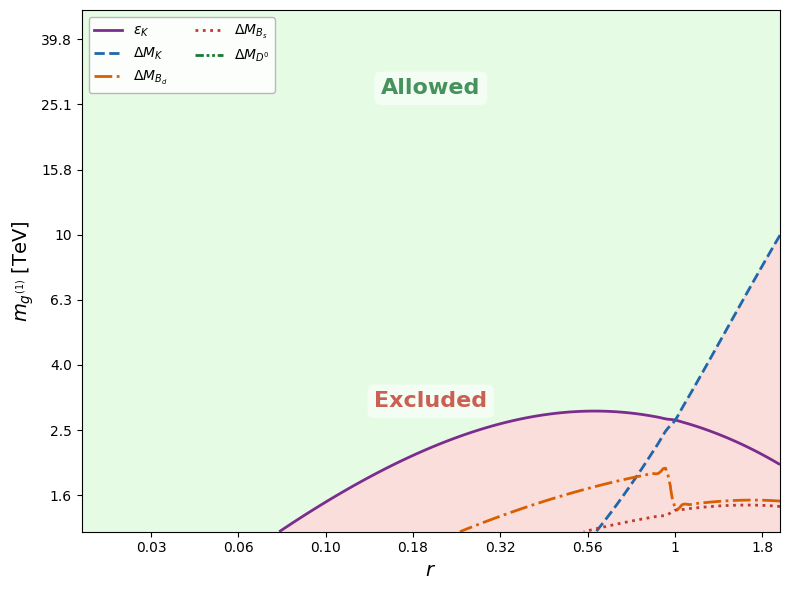

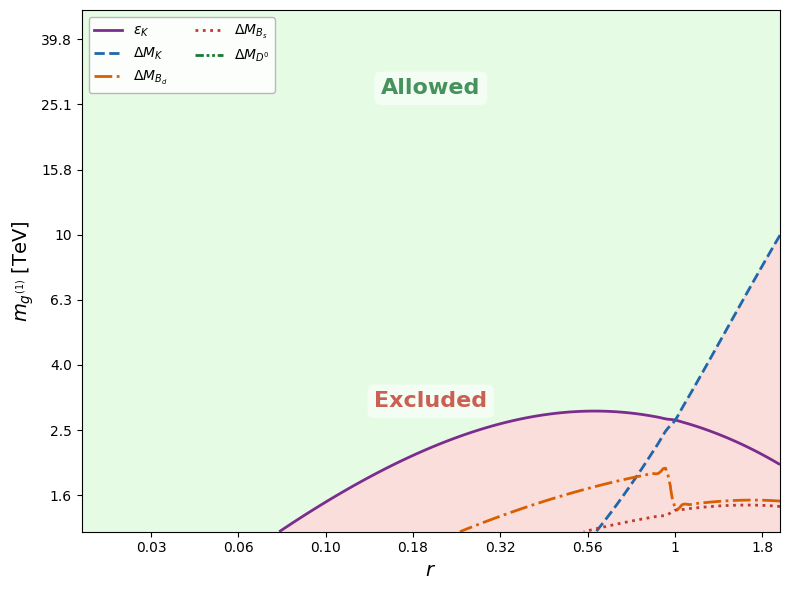

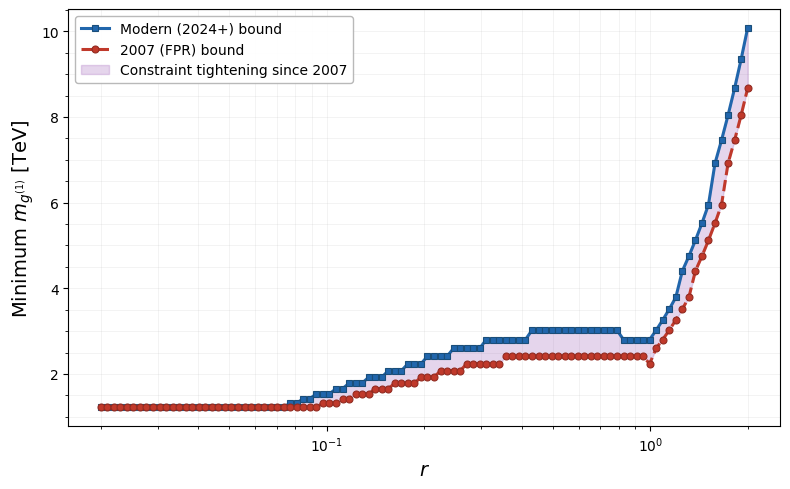

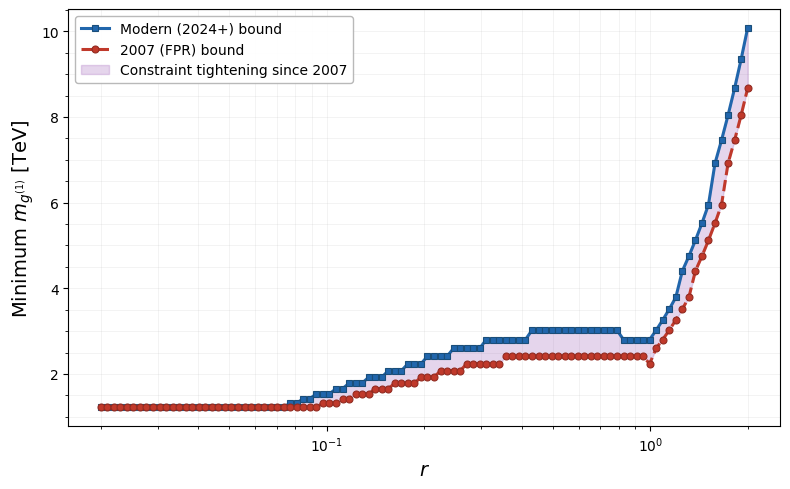

saved fig1_exclusion_boundaries_1sigma.{pdf,png}


saved fig2_mkk_bound_2sigma.{pdf,png}


saved fig2_mkk_bound_1sigma.{pdf,png}


In [5]:
fig1_2s = build_exclusion_boundaries_figure(data_2s)
fig1_1s = build_exclusion_boundaries_figure(data_1s)
fig2_2s = build_mkk_bound_comparison_figure(data_2s)
fig2_1s = build_mkk_bound_comparison_figure(data_1s)

for fig, name in [
    (fig1_2s, 'fig1_exclusion_boundaries_2sigma'),
    (fig1_1s, 'fig1_exclusion_boundaries_1sigma'),
    (fig2_2s, 'fig2_mkk_bound_2sigma'),
    (fig2_1s, 'fig2_mkk_bound_1sigma'),
]:
    if fig is None:
        print(f'skipped {name} (insufficient grid)')
        continue
    fig.savefig(FIG_DIR / f'{name}.pdf', bbox_inches='tight')
    fig.savefig(FIG_DIR / f'{name}.png', bbox_inches='tight', dpi=200)
    print(f'saved {name}.{{pdf,png}}')
    plt.show()

## Step 4 — Yukawa distributions: 2σ vs 1σ

saved yukawa_d_2sigma_vs_1sigma


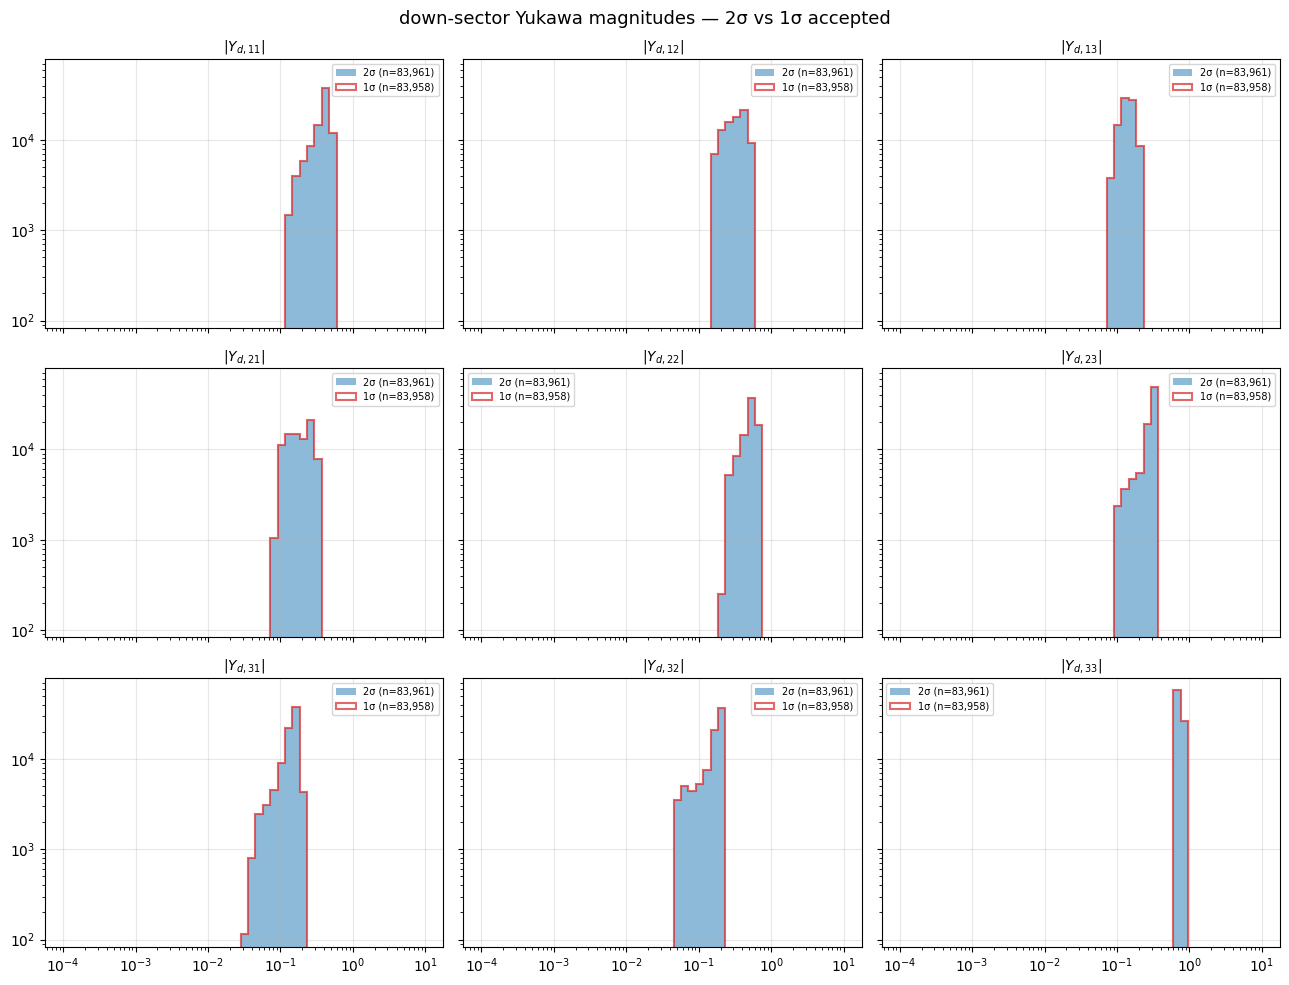

saved yukawa_u_2sigma_vs_1sigma


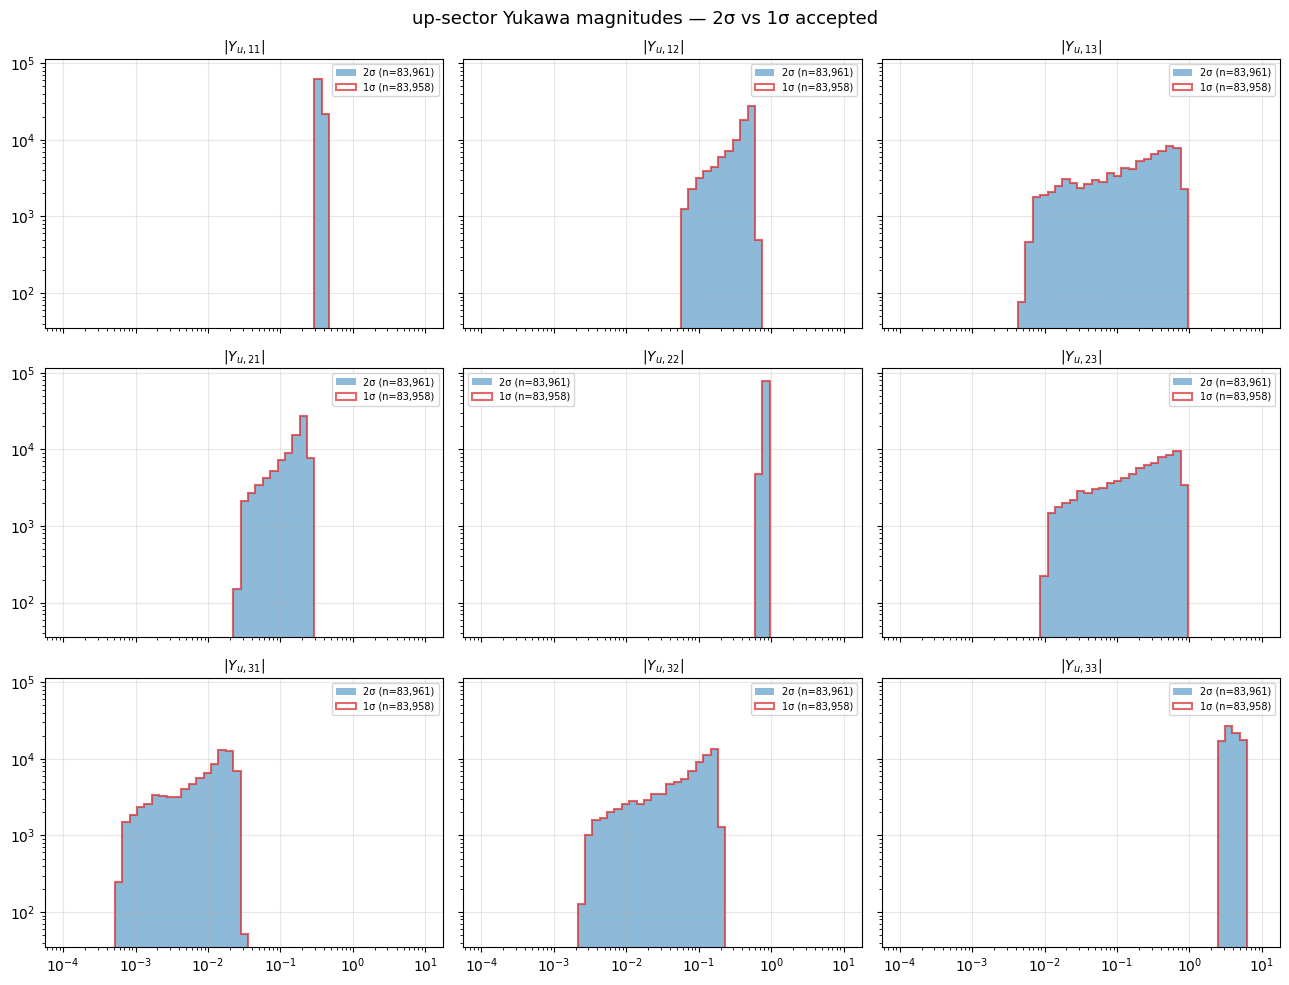

In [6]:
if yk_2s is not None:
    def _abs_entries(df, prefix):
        out = {}
        for i in (1, 2, 3):
            for j in (1, 2, 3):
                out[f'{prefix}_{i}{j}'] = np.hypot(df[f'{prefix}_{i}{j}_re'].values, df[f'{prefix}_{i}{j}_im'].values)
        return out

    abs_yu_2s = _abs_entries(yk_2s, 'Y_u')
    abs_yu_1s = _abs_entries(yk_1s, 'Y_u')
    abs_yd_2s = _abs_entries(yk_2s, 'Y_d')
    abs_yd_1s = _abs_entries(yk_1s, 'Y_d')

    bins = np.logspace(-4, 1, 50)
    for sector, abs_2s, abs_1s, fname in [
        ('down', abs_yd_2s, abs_yd_1s, 'yukawa_d_2sigma_vs_1sigma'),
        ('up',   abs_yu_2s, abs_yu_1s, 'yukawa_u_2sigma_vs_1sigma'),
    ]:
        fig, axs = plt.subplots(3, 3, figsize=(13, 10), sharex=True, sharey=True)
        for i in range(3):
            for j in range(3):
                ax = axs[i, j]
                v_2s = abs_2s[f'Y_{sector[0]}_{i+1}{j+1}']
                v_1s = abs_1s[f'Y_{sector[0]}_{i+1}{j+1}']
                v_2s = v_2s[v_2s > 0]
                v_1s = v_1s[v_1s > 0]
                ax.hist(v_2s, bins=bins, alpha=0.5, label=f'2σ (n={len(v_2s):,})', color='C0')
                ax.hist(v_1s, bins=bins, alpha=0.7, label=f'1σ (n={len(v_1s):,})', color='C3', histtype='step', linewidth=1.5)
                ax.set_xscale('log'); ax.set_yscale('log')
                ax.set_title(f'$|Y_{{{sector[0]},{i+1}{j+1}}}|$', fontsize=10)
                ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
        fig.suptitle(f'{sector}-sector Yukawa magnitudes — 2σ vs 1σ accepted', fontsize=13)
        fig.tight_layout()
        fig.savefig(FIG_DIR / f'{fname}.png', dpi=200, bbox_inches='tight')
        fig.savefig(FIG_DIR / f'{fname}.pdf', bbox_inches='tight')
        print(f'saved {fname}')
        plt.show()

## Step 5 — Bulk-mass parameter (c-value) distributions: 2σ vs 1σ

saved c_values_2sigma_vs_1sigma


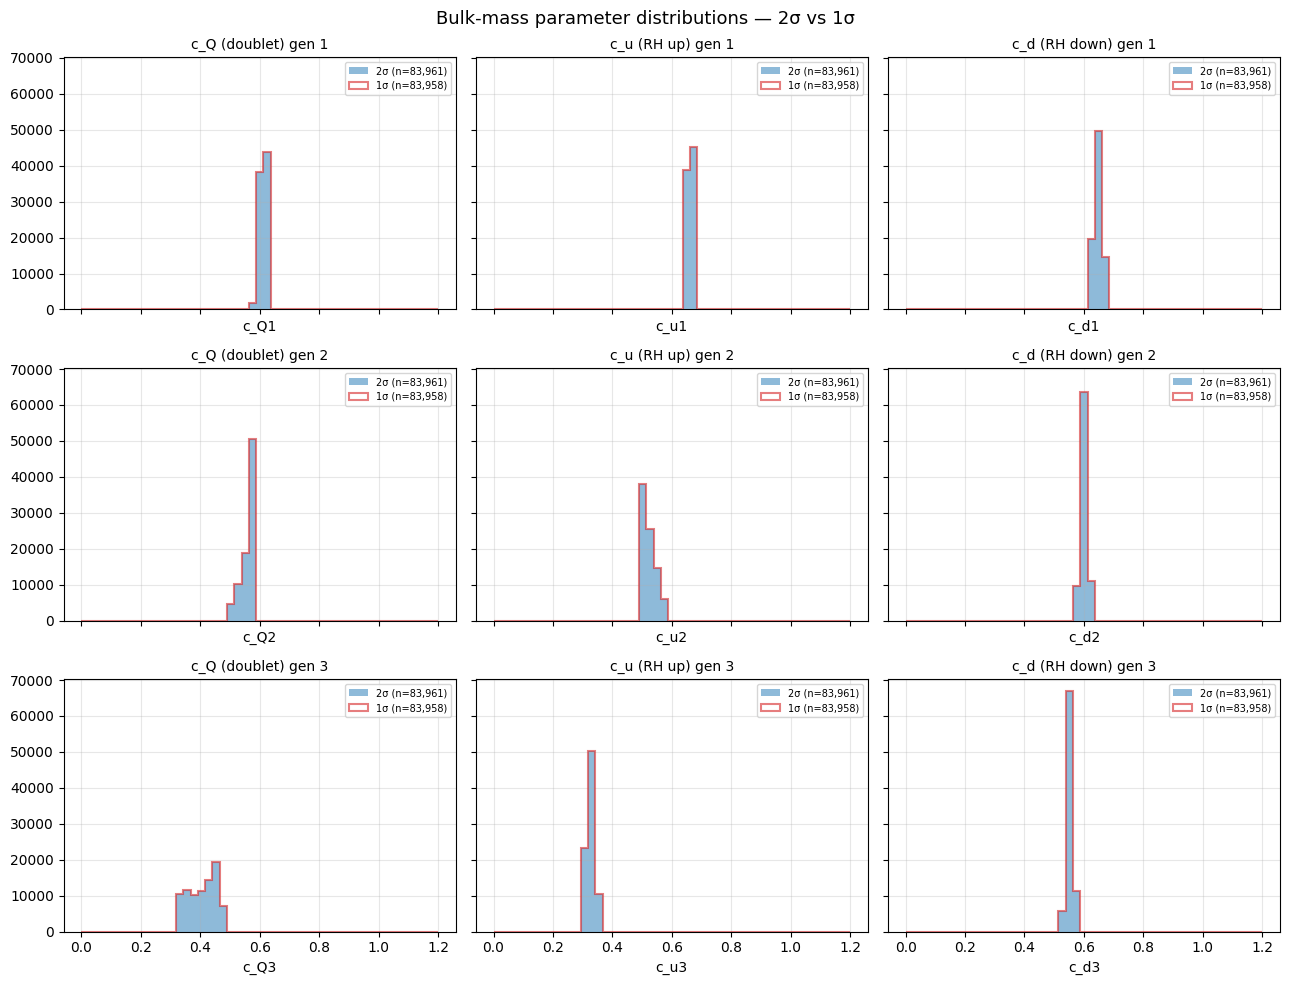

In [7]:
if yk_2s is not None:
    fig, axs = plt.subplots(3, 3, figsize=(13, 10), sharex=True, sharey=True)
    bins = np.linspace(0.0, 1.2, 50)
    for col_idx, (prefix, label) in enumerate([('c_Q', 'c_Q (doublet)'), ('c_u', 'c_u (RH up)'), ('c_d', 'c_d (RH down)')]):
        for gen in (1, 2, 3):
            ax = axs[gen - 1, col_idx]
            col = f'{prefix}{gen}'
            ax.hist(yk_2s[col], bins=bins, alpha=0.5, color='C0', label=f'2σ (n={len(yk_2s):,})')
            ax.hist(yk_1s[col], bins=bins, alpha=0.6, color='C3', histtype='step', linewidth=1.5, label=f'1σ (n={len(yk_1s):,})')
            ax.set_title(f'{label} gen {gen}', fontsize=10)
            ax.set_xlabel(col)
            ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    fig.suptitle('Bulk-mass parameter distributions — 2σ vs 1σ', fontsize=13)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'c_values_2sigma_vs_1sigma.png', dpi=200, bbox_inches='tight')
    fig.savefig(FIG_DIR / 'c_values_2sigma_vs_1sigma.pdf', bbox_inches='tight')
    print('saved c_values_2sigma_vs_1sigma')
    plt.show()

## Step 6 — Headline summary

In [8]:
summary = {
    'run_dir': str(RUN_DIR.relative_to(REPO_ROOT)),
    'total_scanned': 100000,
    'accepted_2sigma': int(n_2s),
    'accepted_1sigma': int(n_1s),
    'tightening_factor_2to1': round(n_2s / max(n_1s, 1), 2),
    'tolerances_2sigma': {k: v.tolist() for k, v in TOLS_2S.items()},
    'tolerances_1sigma': {k: v.tolist() for k, v in TOLS_1S.items()},
    'figures_saved_under': str(FIG_DIR.relative_to(REPO_ROOT)),
    'csv_artifacts': [
        'derived/accepted_points.csv (2σ)',
        'derived/accepted_points_1sigma.csv',
        'derived/accepted_points_with_yukawas.csv (2σ)',
        'derived/accepted_points_with_yukawas_1sigma.csv',
    ],
}
print(json.dumps(summary, indent=2))

{
  "run_dir": "scan_outputs/dense_20260506T141321",
  "total_scanned": 100000,
  "accepted_2sigma": 83958,
  "accepted_1sigma": 83958,
  "tightening_factor_2to1": 1.0,
  "tolerances_2sigma": {
    "up": [
      0.45370370370370366,
      0.007227022780832679,
      0.008615384615384615
    ],
    "down": [
      0.1829787234042553,
      0.017112299465240642,
      0.003346880229500359
    ],
    "ckm": [
      0.0044,
      0.072,
      0.1,
      0.085
    ]
  },
  "tolerances_1sigma": {
    "up": [
      0.22685185185185183,
      0.0036135113904163397,
      0.0043076923076923075
    ],
    "down": [
      0.09148936170212765,
      0.008556149732620321,
      0.0016734401147501794
    ],
    "ckm": [
      0.0022,
      0.036,
      0.05,
      0.0425
    ]
  },
  "figures_saved_under": "results/figures/quark",
  "csv_artifacts": [
    "derived/accepted_points.csv (2\u03c3)",
    "derived/accepted_points_1sigma.csv",
    "derived/accepted_points_with_yukawas.csv (2\u03c3)",
    "